# Exact early-time model

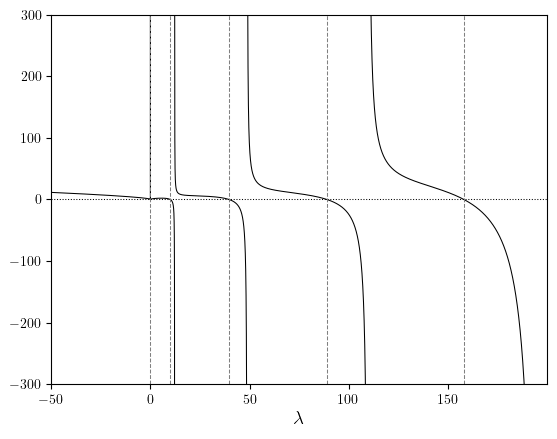

In [1]:
from ipynb_boilerplate import *
import numpy as np
from lucifex.plt import plot_line
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from crocodil.theory.system_a.early import EarlyTimeExactModel, EarlyTimeExactFormulae

X = 1
Ra, Da, zeta0, sr, cr, aspect = SYSTEM_A_REFERENCE['Ra', 'Da', 'zeta0', 'sr', 'cr', 'aspect']
Lmbda = EarlyTimeExactFormulae.Lmbda(Ra, Da, sr)

lmbda_axis = np.arange(-50, 200, 0.01)
lmbda_curve = np.array(
    [EarlyTimeExactFormulae.eigenvalue_characteristic(i, Lmbda, zeta0) for i in lmbda_axis]
)
lmbda_curve[np.abs(lmbda_curve) > 1e3] = np.nan

eigen_guesses = range(1, int(max(lmbda_axis)), 5)
eigenvalues = EarlyTimeExactFormulae.eigenvalues(
    Lmbda, zeta0, eigen_guesses,
)

fig, ax = plot_line(
    (lmbda_axis, lmbda_curve),
    x_label='$\lambda$',
)
y_lims = (-300, 300)
ax.set_ylim(*y_lims)
ax.hlines(0, min(lmbda_axis), max(lmbda_axis), linestyles='dotted', colors='black', linewidths=0.75)
ax.vlines(eigenvalues, *y_lims, linestyles='dashed', colors='grey', linewidths=0.75)

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='$y$'>)

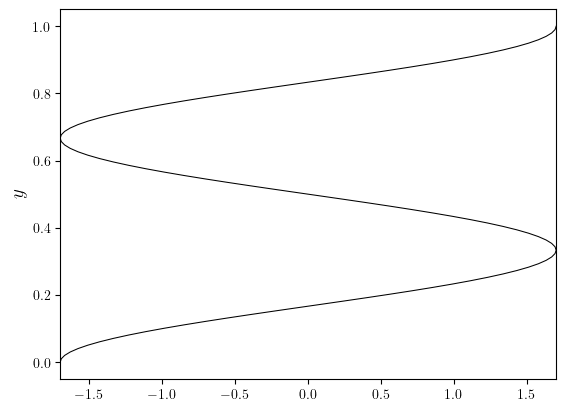

In [2]:
t = np.linspace(1e-6, 120.0, 100)
y = np.linspace(0, X, 100)
exact_model = EarlyTimeExactModel(t, y, Ra, Da, zeta0, sr, cr, eigen_guesses)

plot_line(
    (exact_model.y, exact_model.eigenfunction(3)),
    flip=True,
    y_label='$y$',
)

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='$y$'>)

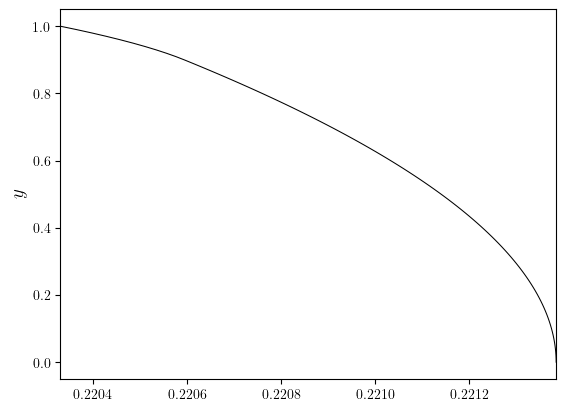

In [5]:
t = 0.1

plot_line(
    (exact_model.y, exact_model.c(t)),
    flip=True,
    # x_label='$c_{\mathrm{b}}$',
    y_label='$y$',
)


In [5]:
exact_model.eigenvalues

[0.002498313309819817,
 9.874443238425505,
 39.48281014432699,
 88.83020139435261,
 157.9167553817623,
 246.74261019790387]

In [6]:
exact_model.coefficients

[1.0006082211006542,
 -0.038438259064899505,
 -0.03128589558228436,
 -0.020786200160078643,
 -0.009588206827815401,
 -1.8603473267711495e-06]

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='$y$'>)

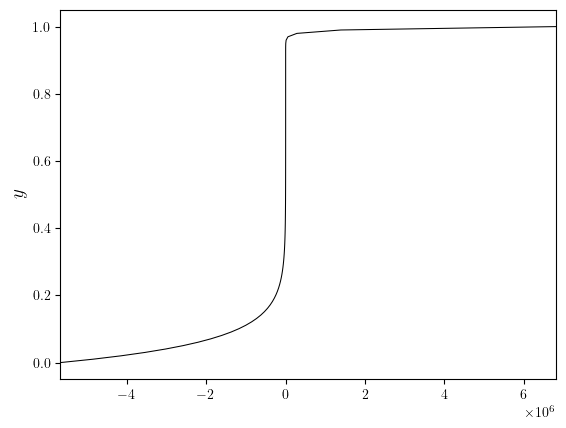

In [6]:
Ln = eigenvalues[-1]

plot_line(
    (exact_model.y, [EarlyTimeExactFormulae.Yn(i, Ln, Lmbda, zeta0) for i in exact_model.y]),
    flip=True,
    y_label='$y$',
)

In [3]:
exact_model.eigenvalues

array([  3.00380779,  27.03420964,  75.09469037, 147.18460192,
       243.30296698])